In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

%matplotlib widget


In [2]:
# ── Dyad identification ──────────────────────────────────────────────────────
DYAD_NR = '030'
DEV_CG  = 'A839C92B'   # Caregiver H10 device ID
DEV_CH  = 'A83E1E24'   # Child H10 device ID


Auto-detected latest recording for W_030: 29_07_2025 12_34, CH=A83E1E24, CG=A839C92B
Detected events: {'Brave': {'name': 'Brave', 'start': 387.806640625, 'duration': 59.3310546875}, 'Peppa': {'name': 'Peppa', 'start': 248.5107421875, 'duration': 59.6328125}, 'Incredibles': {'name': 'Incredibles', 'start': 318.3603515625, 'duration': 59.212890625}, 'Talk_1': {'name': 'Talk_1', 'start': 594.4892578125, 'duration': 181.0556640625}, 'Talk_2': {'name': 'Talk_2', 'start': 836.7275390625, 'duration': 181.056640625}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Peppa
ET time range: 241.59s to 461.89s
Events from ET annotations:
[None 'Peppa' 'Incredibles' 'Brave']
Reseting the ET time to the start of Peppa
Processing member: ch, blink column: ET_ch_blinks
Processing member: cg, blink column: ET_cg_blinks
Column ET_ch_blinks contains NaN values, applying forward and backward fill before decimation.
Column ET_cg_blinks contains NaN values, applying forward and backward

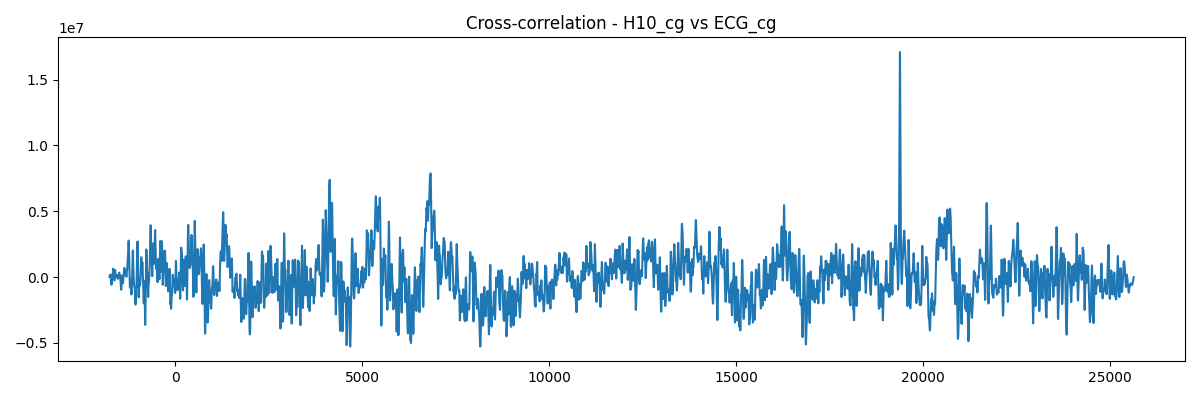

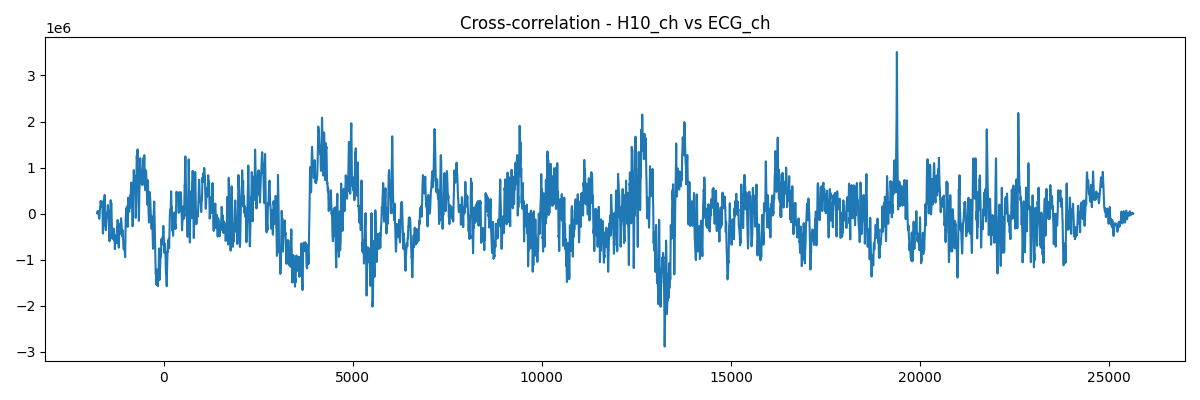

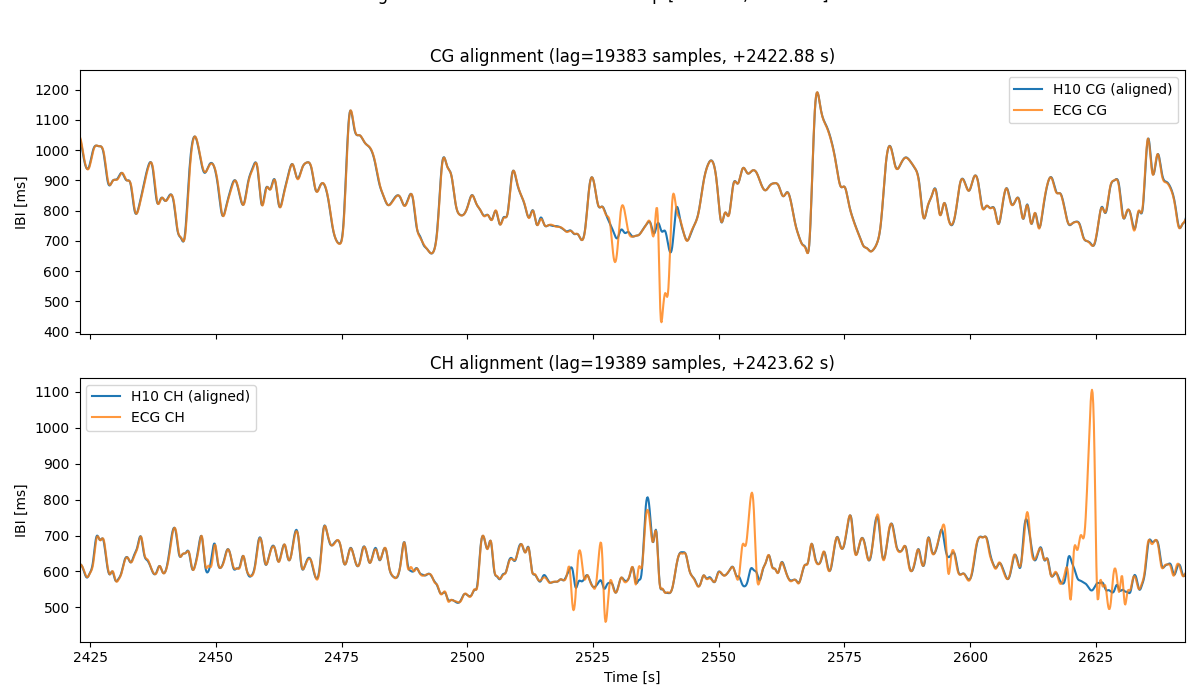

<xarray.DataArray 'H10_IBI_RMSSD_events' (time: 25632, channel: 5)> Size: 1MB
array([[511.62596769, 580.60003734,   3.90625   ,  45.8984375 ,
          0.        ],
       [510.92497467, 628.54125701,   3.90625   ,  45.8984375 ,
          0.        ],
       [508.00080146, 666.83614551,   3.90625   ,  45.8984375 ,
          0.        ],
       ...,
       [576.84658345, 771.50327513,  29.05486481,  50.79493076,
          0.        ],
       [577.03631437, 780.44559806,  29.05486481,  50.79493076,
          0.        ],
       [579.02267223, 788.28739818,  29.30644758,  50.90565353,
          0.        ]], shape=(25632, 5))
Coordinates:
  * time     (time) float64 205kB -116.1 -116.0 -115.9 ... 3.088e+03 3.088e+03
  * channel  (channel) <U8 160B 'IBI_CH' 'IBI_CG' 'RMSSD_CH' 'RMSSD_CG' 'events'
Attributes: (12/13)
    sampling_frequency_Hz:  8
    dyad_id:                W_030
    window_size_RMSSD_s:    30
    device_CH:              A83E1E24
    device_CG:              A839C92B
    rec

In [3]:
from src.secore_loader import build_h10_ibi_rmssd_xarray_auto

# One-line call: only dyad number (with notebook-level preferred device IDs)
h10_xarray = build_h10_ibi_rmssd_xarray_auto(
    dyad_nr=DYAD_NR,
    plot=True,
    preferred_dev_ch=DEV_CH,
    preferred_dev_cg=DEV_CG,
)

print(h10_xarray)
print(f'\nshape: {h10_xarray.shape}')
print(f'sampling_frequency_Hz: {h10_xarray.attrs["sampling_frequency_Hz"]}')


# Plots of IBI and RMSSD with events marked based on the xarray information

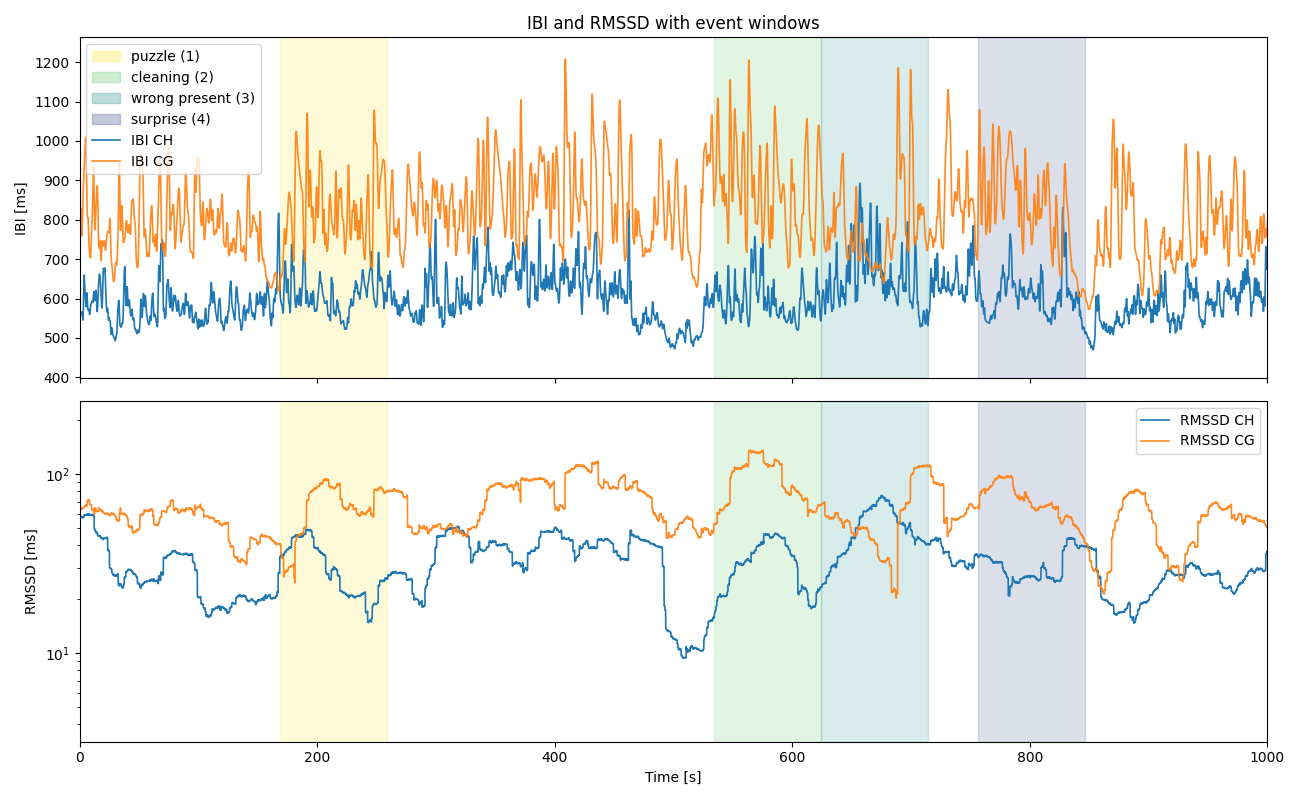

In [6]:
# Extract time axis and channels from xarray
t = h10_xarray.coords['time'].values
ibi_ch = h10_xarray.sel(channel='IBI_CH').values
ibi_cg = h10_xarray.sel(channel='IBI_CG').values
rmssd_ch = h10_xarray.sel(channel='RMSSD_CH').values
rmssd_cg = h10_xarray.sel(channel='RMSSD_CG').values

# Event metadata from attrs
event_code_map = json.loads(h10_xarray.attrs.get('event_code_map_json', '{}'))
event_windows_s = json.loads(h10_xarray.attrs.get('event_windows_s_json', '{}'))

# Define colors per event (fallback to neutral when missing)
event_colors = {
    'puzzle': '#fde725',
    'cleaning': '#5ec962',
    'wrong present': '#21918c',
    'surprise': '#3b528b',
}

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(13, 8))

# IBI panel
axes[0].plot(t, ibi_ch, label='IBI CH', lw=1.2)
axes[0].plot(t, ibi_cg, label='IBI CG', lw=1.2, alpha=0.9)
axes[0].set_ylabel('IBI [ms]')
axes[0].set_title('IBI and RMSSD with event windows')

# RMSSD panel
axes[1].semilogy(t, rmssd_ch, label='RMSSD CH', lw=1.2)
axes[1].semilogy(t, rmssd_cg, label='RMSSD CG', lw=1.2, alpha=0.9)
axes[1].set_ylabel('RMSSD [ms]')
axes[1].set_xlabel('Time [s]')

# Shade event windows on both axes
for event_name, window in event_windows_s.items():
    if event_name == 'baseline':
        continue
    start = float(window['start_s'])
    end = float(window['end_s'])
    color = event_colors.get(event_name, '#bbbbbb')
    for ax in axes:
        ax.axvspan(start, end, color=color, alpha=0.18)

# Build combined signal + event legend
event_handles = []
for event_name, code in sorted(event_code_map.items(), key=lambda kv: kv[1]):
    if event_name == 'baseline':
        continue
    color = event_colors.get(event_name, '#bbbbbb')
    event_handles.append(plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.3, label=f'{event_name} ({code})'))

signal_handles_0 = axes[0].get_legend_handles_labels()[0]
axes[0].legend(handles=event_handles + signal_handles_0, loc='upper left')
axes[1].legend(loc='upper right')

axes[0].set_xlim(0,1000)  # Focus on first ~17 minutes
axes[1].set_xlim(0,1000)  # Focus on first ~17 minutes

plt.tight_layout()
plt.show()


## RMSSD in Short (~30s) Time Windows
RMSSD (Root Mean Square of Successive Differences) is the square root of the mean of squared differences between consecutive RR intervals. In short windows, it is the standard proxy for vagal (parasympathetic) modulation of heart rate.

### What it reflects physiologically
- RMSSD captures high-frequency beat-to-beat variability, which is almost exclusively driven by the vagus nerve acting on the sinoatrial node via acetylcholine. 
- Sympathetic influence operates too slowly (several seconds of latency) to meaningfully affect successive-beat differences, so RMSSD is considered sympathetically insensitive at short timescales — a key advantage over measures like SDNN or LF/HF power.
- In practical terms, high RMSSD → strong vagal tone → greater cardiac parasympathetic activity.

### Validity in ~30s windows
The standard recommendation (Task Force 1996) is 5-minute windows for reliable HRV. However, 30s RMSSD is empirically well-validated:

It correlates very strongly (r > 0.9) with 5-min RMSSD across many populations
It is the basis of ultra-short HRV research (Esco, Flatt, and colleagues), which showed that 1-min windows are generally sufficient, and 30s windows are usable with caution
The key limitation is stationarity — 30s may capture fewer than ~30 beats at rest, making the estimate noisier, especially if there are ectopic beats or motion artifacts


### What 30s RMSSD tells you in practice


- Resting baseline: Tonic vagal tone; high values indicate good autonomic health
- Post-stimulus (e.g., cognitive load, stress): Rapid vagal withdrawal is detectable within seconds — RMSSD drops fast
- Recovery monitoring (exercise, stress): Vagal reactivation speed; RMSSD recovers faster in fit/healthy individuals